# ESC-50: CNN on log-mel spectrograms

The input is the log-mel spectrogram (128 mel bands x 216 frames at 22.05 kHz): the MFCC pipeline
without the DCT and without averaging over time, so the time-frequency structure is kept.
The network (`audiolab.model.AudioCNN`) has 4 blocks of 3x3 convolution, batch norm, ReLU and
2x2 max pooling (16, 32, 64, 128 filters), then averages over time and classifies.

Three configurations, trained with `scripts/train_cnn_esc50.py` (40 epochs, AdamW, one-cycle
learning rate, fixed *before* looking at any test result) and evaluated on the 5 official folds:

| Name | Frequency position at the end | Augmentation |
|---|---|---|
| `cnn_freq` | kept | time shift + SpecAugment |
| `cnn_global` | averaged away | time shift + SpecAugment |
| `cnn_freq_noaug` | kept | none |

In [1]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

from audiolab.esc50 import GROUPS, load_metadata
from audiolab.evaluation import fold_accuracies, predict_on_folds

DATA = Path("../data")
meta = load_metadata(DATA / "ESC-50")
y = meta.target.to_numpy()
folds = meta.fold.to_numpy()
class_names = meta.drop_duplicates("target").set_index("target").category.sort_index()

results = {name: np.load(DATA / "results" / f"{name}.npz") for name in ["cnn_freq", "cnn_global", "cnn_freq_noaug"]}
preds = {name: r["pred"] for name, r in results.items()}

# The MFCC + Random Forest baseline of notebook 03, for comparison
X_mfcc = np.load(DATA / "cache" / "esc50_mfcc.npy")
preds["mfcc_rf"] = predict_on_folds(RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1),
                                    X_mfcc, y, folds)

## 1. Accuracy

In [2]:
LABELS = {"mfcc_rf": "MFCC + Random Forest", "cnn_global": "CNN, frequency averaged",
          "cnn_freq_noaug": "CNN, no augmentation", "cnn_freq": "CNN (frequency kept)"}
accs = {name: fold_accuracies(y, p, folds) for name, p in preds.items()}

table = pd.DataFrame({
    "accuracy": [f"{a.mean():.1%} ± {a.std():.1%}" for a in accs.values()],
    **{f"fold {k}": [f"{a[k - 1]:.1%}" for a in accs.values()] for k in range(1, 6)},
    "weights": [f"{int(results[n]['n_weights']):,}" if n in results else "-" for n in accs],
}, index=[LABELS[n] for n in accs])
table

,accuracy,fold 1,fold 2,fold 3,fold 4,fold 5,weights
CNN (frequency kept),76.5% ± 2.7%,75.5%,79.2%,78.8%,77.2%,71.8%,"148,642"
"CNN, frequency averaged",62.9% ± 1.1%,63.7%,63.0%,63.7%,63.2%,60.8%,"103,842"
"CNN, no augmentation",76.2% ± 3.4%,74.2%,77.8%,76.2%,81.5%,71.5%,"148,642"
MFCC + Random Forest,47.6% ± 2.1%,44.5%,51.0%,48.2%,47.2%,47.2%,-


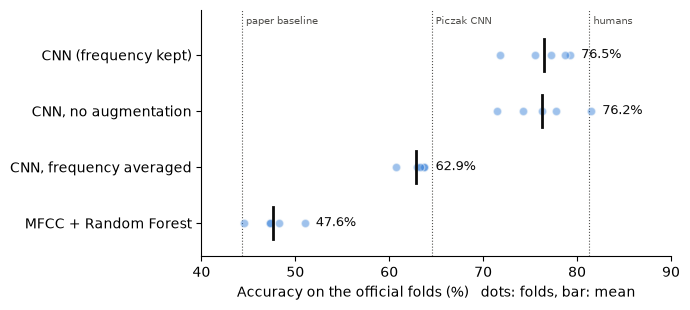

In [3]:
order = ["mfcc_rf", "cnn_global", "cnn_freq_noaug", "cnn_freq"]
fig, ax = plt.subplots(figsize=(7, 3.2))
for i, name in enumerate(order):
    a = accs[name] * 100
    ax.scatter(a, np.full(5, i), s=36, color="#2a78d6", alpha=0.45, edgecolor="#fcfcfb", linewidth=1, zorder=3)
    ax.plot([a.mean()] * 2, [i - 0.28, i + 0.28], color="#0b0b0b", linewidth=2, zorder=4)
    ax.annotate(f"{a.mean():.1f}%", (a.max(), i), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=9, color="#0b0b0b")
for ref, label in [(44.3, "paper baseline"), (64.5, "Piczak CNN"), (81.3, "humans")]:
    ax.axvline(ref, color="#52514e", linewidth=0.8, linestyle=":")
    ax.annotate(label, (ref, len(order) - 0.45), xytext=(3, 0), textcoords="offset points",
                fontsize=7.5, color="#52514e")
ax.set_yticks(range(len(order)), [LABELS[n] for n in order])
ax.set_xlabel("Accuracy on the official folds (%)   dots: folds, bar: mean")
ax.set_xlim(40, 90)
ax.set_ylim(-0.6, len(order) - 0.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 2. Training loss: information vs. memorization

The training loss is measured on the clips the network learns from, so it shows how well it
*fits* them, not how well it generalizes.

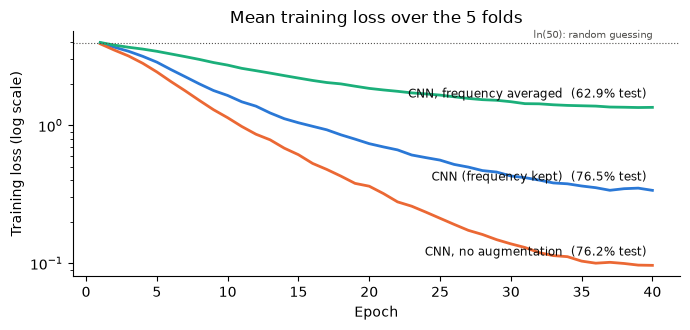

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.4))
styles = {"cnn_freq": ("#2a78d6", "-"), "cnn_freq_noaug": ("#eb6834", "-"), "cnn_global": ("#1baf7a", "-")}
for name, (color, ls) in styles.items():
    mean_loss = results[name]["losses"].mean(axis=0)
    epochs = np.arange(1, len(mean_loss) + 1)
    ax.plot(epochs, mean_loss, color=color, linewidth=2, linestyle=ls)
    ax.annotate(f"{LABELS[name]}  ({accs[name].mean():.1%} test)", (epochs[-1], mean_loss[-1]),
                xytext=(-4, 7), textcoords="offset points", ha="right", fontsize=8.5, color="#0b0b0b")
ax.axhline(np.log(50), color="#52514e", linewidth=0.8, linestyle=":")
ax.annotate("ln(50): random guessing", (40, np.log(50)), xytext=(0, 4), textcoords="offset points",
            ha="right", fontsize=7.5, color="#52514e")
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss (log scale)")
ax.set_title("Mean training loss over the 5 folds")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Which classes improve with the CNN?

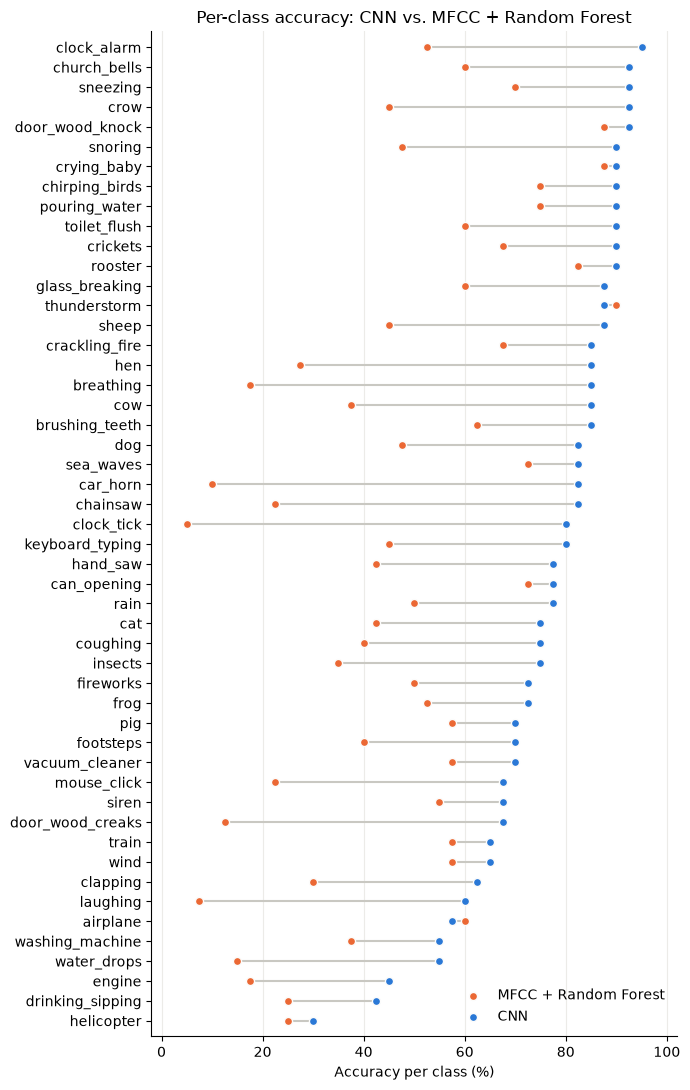

In [5]:
per_class = pd.DataFrame({
    name: pd.Series(p == y).groupby(y).mean() for name, p in preds.items()
}).rename(index=class_names)
per_class["group"] = meta.drop_duplicates("target").set_index("target").group.sort_index().to_numpy()
per_class["gain"] = per_class.cnn_freq - per_class.mfcc_rf
per_class = per_class.sort_values("cnn_freq")

fig, ax = plt.subplots(figsize=(7, 11))
rows = np.arange(len(per_class))
ax.hlines(rows, per_class.mfcc_rf * 100, per_class.cnn_freq * 100, color="#c9c8c2", linewidth=1.5, zorder=1)
ax.scatter(per_class.mfcc_rf * 100, rows, s=34, color="#eb6834", edgecolor="#fcfcfb", linewidth=1, zorder=3,
           label="MFCC + Random Forest")
ax.scatter(per_class.cnn_freq * 100, rows, s=34, color="#2a78d6", edgecolor="#fcfcfb", linewidth=1, zorder=3,
           label="CNN")
ax.set_yticks(rows, per_class.index)
ax.set_xlabel("Accuracy per class (%)")
ax.set_xlim(-2, 102)
ax.set_ylim(-0.8, len(per_class) - 0.2)
ax.set_title("Per-class accuracy: CNN vs. MFCC + Random Forest")
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="x", color="#ecebe8", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [6]:
print("Biggest gains (points):")
print((per_class.gain.sort_values(ascending=False).head(8) * 100).round(0).to_string())
print("\nClasses where the CNN is not better:")
print((per_class.gain[per_class.gain <= 0] * 100).round(0).to_string())

Biggest gains (points):
clock_tick          75.0
car_horn            72.0
breathing           68.0
chainsaw            60.0
hen                 57.0
door_wood_creaks    55.0
laughing            52.0
crow                48.0

Classes where the CNN is not better:
airplane       -3.0
thunderstorm   -3.0


In [7]:
results_cnn = pd.DataFrame({"true": meta.category, "pred": class_names[preds["cnn_freq"]].to_numpy()})
print("Most frequent CNN confusions (true -> predicted, out of 40 clips per class):")
results_cnn[results_cnn.true != results_cnn.pred].value_counts(["true", "pred"]).head(10)

Most frequent CNN confusions (true -> predicted, out of 40 clips per class):


true        pred        
engine      helicopter      7
clapping    rain            6
train       airplane        5
sea_waves   rain            5
airplane    thunderstorm    5
helicopter  airplane        5
laughing    hen             5
helicopter  engine          5
train       wind            4
helicopter  rain            4
Name: count, dtype: int64

## 4. What does the frequency position buy?

Averaging over frequency makes the network blind to *where* a pattern is: a steady tone at 400 Hz
looks like a steady tone at 3 kHz. Which classes lose the most without it?

In [8]:
freq_gain = (per_class.cnn_freq - per_class.cnn_global).sort_values(ascending=False)
print("Classes that gain most from keeping the frequency position (points):")
print((freq_gain.head(8) * 100).round(0).to_string())
print(f"\nClasses that gain: {(freq_gain > 0).sum()} of 50 | lose: {(freq_gain < 0).sum()}")

Classes that gain most from keeping the frequency position (points):
car_horn            45.0
hen                 45.0
door_wood_creaks    38.0
breathing           38.0
crow                38.0
can_opening         35.0
glass_breaking      35.0
coughing            32.0

Classes that gain: 40 of 50 | lose: 6


## Conclusions

- **76.5% ± 2.7%**, 29 points above MFCC + Random Forest (47.6%) and 12 above the original CNN
  baseline of the dataset paper (64.5%), with 149k weights trained on a laptop CPU in 47 minutes.
  Humans reach 81.3%.
- **Time structure was the missing piece.** The largest gains are exactly the classes defined by a
  temporal pattern that averaging MFCCs destroys: clock tick +75 points (5% to 80%), car horn +72,
  breathing +68. The CNN is only (slightly) worse on 2 classes.
- **Frequency position matters (and the ear agrees).** Averaging over frequency at the end costs
  13.6 points, and the training loss shows why: that network cannot even fit the training set
  (loss 1.36 vs 0.33), it lacks information, it is not memorizing less. Car horn and hen lose 45
  points each: a steady tone is a horn or an alarm depending on *where* it sits in frequency.
- **Augmentation did not help here** (76.5% vs 76.2%, the per-fold differences go both ways).
  Without it the network fits the training set much more closely (loss 0.10) with the same test
  accuracy. One likely reason: the random time shift is redundant with an architecture that already
  averages over time. Augmentation is not free accuracy; it has to add variability the model does
  not already ignore.
- **Remaining errors are reasonable ones**: engine, helicopter, airplane and train (continuous
  low-frequency noise), clapping, sea waves and rain (broadband noise-like textures).